In [1]:
import pandas as pd
import numpy as np
pd.options.display.max_rows=None
import warnings
warnings.filterwarnings(action='ignore')

# 날씨

In [3]:
df = pd.read_csv("data/날씨통합.csv")

#항공 데이터엔 날짜와 시간이 따로 나와있기 때문에 공백을 기준으로 컬럼 나눔
df[['날짜', '날씨측정시간']] = df['일시'].str.split(' ', n=1, expand=True) 
#일시 컬럼 포함) 필요 없는 컬럼 제거
df= df.drop(columns=['일시','1층 운형','2층 운형','3층 운형','4층 운형'])
#편리함을 위해 시간에서 :을 제외
df['날씨측정시간'] = df['날씨측정시간'].str.replace(':', '', regex=False) 

df['날짜'] = df['날짜'].str.replace('-', '', regex=False) #편리함을 위해 날짜에서 -를 제외
weather=df #데이터 혼합을 방지하기 위해 새로운 변수에 데이터셋 복사

weather.head(1)

,지점,지점명,풍향(deg),풍속(KT),순간풍속(KT),시정(m),일기현상,전운량(1/8),1층 운량(1/8),2층 운량(1/8),...,2층 운고(FT),3층 운고(FT),4층 운고(FT),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날짜,날씨측정시간
0,113,인천공항,40,3,NaN,10000,NaN,2,2.0,NaN,...,NaN,NaN,NaN,21.5,19.9,1011.4,1010.6,NaN,20220901,0000


# 항공기

In [5]:
df3 = pd.read_csv("data/항공편_전체정보.csv", encoding='cp949') #항공기 데이터셋 샘플
df3.head()

,출/도착구분,날짜,항공사,편명,출발공항코드,출발공항명,도착공항코드,도착공항명,계획시간,예상시간,출발시간,구분,현황
0,출발,20220901,아시아나항공,OZ933,ICN,인천,HAN,노이바이(하노이),00:05,23:50,00:25,화물,출발
1,출발,20220901,아시아나항공,OZ387,ICN,인천,HAN,노이바이(하노이),00:05,23:55,00:09,화물,출발
2,출발,20220901,아시아나항공,OZ967,ICN,인천,HKG,홍콩,00:05,23:45,00:23,화물,출발
3,출발,20220901,칼리타항공,K4852,ICN,인천,ANC,앵커리지,00:05,00:00,00:21,화물,출발
4,출발,20220901,대한항공,KE373,ICN,인천,PEN,페낭,00:05,00:00,00:19,화물,출발


In [6]:
df3 = df3.drop("예상시간", axis=1) #필요 없는 변수 제거
#편리함을 위해 시간에서 :을 제외
df3['계획시간'] = df3['계획시간'].str.replace(':', '', regex=False) 
df3['출발시간'] = df3['출발시간'].str.replace(':', '', regex=False)
airplane_info = df3 #데이터 혼합을 방지하기 위해 새로운 변수에 데이터셋 복사

#국내 저가 항공사만 남김
airplane_info = airplane_info[airplane_info['항공사'].isin(['진에어', '제주항공', '티웨이항공', '에어부산'])] 
airplane_info.head(1)

,출/도착구분,날짜,항공사,편명,출발공항코드,출발공항명,도착공항코드,도착공항명,계획시간,출발시간,구분,현황
47,출발,20220901,제주항공,7C4407,ICN,인천,TAG,팡라로,0700,0716,여객,출발


In [7]:
df4= pd.read_csv("data/air.csv", encoding='cp949') #사유 데이터 불러오기
df4 = df4.drop(columns=['도착공항명','계획시간','예상시간','출발시간','구분','현황']) #필요 없는 컬럼 삭제
df4.head(1)

,날짜,편명,사유
0,20220901,KD7363,연결-항공기


In [8]:
airplane_reason=df4  #데이터셋 복사

# 합치기

In [10]:
# 데이터타입이 다를 경우 나오지 않기 때문에 형식 변환
airplane_info['날짜'] = airplane_info['날짜'].astype(str)
airplane_info['계획시간'] = airplane_info['계획시간'].astype(str)
weather['날짜'] = weather['날짜'].astype(str)
weather['날씨측정시간'] = weather['날씨측정시간'].astype(str)

airplane_reason['날짜'] = airplane_reason['날짜'].astype(str)

In [11]:
# airplane_info에서 계획시간을 시각으로 변환 (분단위 제거) => 항공기는 출발 직전의 최신 기상 데이터를 참고할 것이고 날씨 데이터는 1시간 단위로 측정되기 때문에 분단위 고려 안 함
airplane_info['계획시간_시'] = airplane_info['계획시간'].str[:2] + '00'

# 날짜와 시간 기준으로 병합
airplane_merged = pd.merge(airplane_info, weather, left_on=['날짜', '계획시간_시'], right_on=['날짜', '날씨측정시간'], how='left')

# 결과에서 시간_시 대신 weather의 시간 컬럼을 그대로 표시
airplane_merged = airplane_merged.drop(columns=['계획시간_시'])

In [12]:
# 날짜와 편명 기준으로 병합
airplane_merged = pd.merge(airplane_merged, airplane_reason, left_on=['날짜', '편명'], right_on=['날짜', '편명'], how='left')

#합쳐진 원본 테이블 airplane_mergeed에 복사
airplane_merged.head()

,출/도착구분,날짜,항공사,편명,출발공항코드,출발공항명,도착공항코드,도착공항명,계획시간,출발시간,...,2층 운고(FT),3층 운고(FT),4층 운고(FT),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간,사유
0,출발,20220901,제주항공,7C4407,ICN,인천,TAG,팡라로,0700,0716,...,NaN,NaN,NaN,20.8,18.9,1013.8,1013.0,NaN,0700,NaN
1,출발,20220901,티웨이항공,TW125,ICN,인천,DAD,다낭,0745,0754,...,NaN,NaN,NaN,20.8,18.9,1013.8,1013.0,NaN,0700,NaN
2,출발,20220901,티웨이항공,TW139,ICN,인천,KLO,칼리보,0800,0816,...,NaN,NaN,NaN,21.8,19.0,1014.1,1013.3,NaN,0800,NaN
3,출발,20220901,티웨이항공,TW281,ICN,인천,KIX,간사이,0800,0818,...,NaN,NaN,NaN,21.8,19.0,1014.1,1013.3,NaN,0800,NaN
4,출발,20220901,진에어,LJ077,ICN,인천,DAD,다낭,0800,0820,...,NaN,NaN,NaN,21.8,19.0,1014.1,1013.3,NaN,0800,NaN


# 전처리

### 필요 없는 열 제거

In [15]:
airplane_merged['현황'].value_counts()

현황
출발    56088
지연    23231
취소       85
회항       41
Name: count, dtype: int64

In [16]:
airplane_merged=airplane_merged[(airplane_merged['구분'] == '여객')]  #화물과 기타는 제외하고 여객만 다룸
#취소, 회황 데이터가 너무 적어서 삭제함
airplane_merged = airplane_merged[(airplane_merged['현황'] == '지연') | (airplane_merged['현황'] == '출발')]

airplane_merged=airplane_merged.drop("순간풍속(KT)", axis=1)  #데이터 값이 띄엄띄엄 있어 결측치 처리에 어렵기 때문에 제거

In [17]:
 #필요 없는 컬럼 삭제
airplane_merged=airplane_merged.drop(columns=['출/도착구분','출발공항코드','출발공항명','도착공항코드','지점','지점명'],axis=1) 

In [18]:
airplane_merged=airplane_merged.drop("사유", axis=1) #필요없어진 사유 컬럼 제거

In [19]:
#필요없는 컬럼 삭제한 뒤 airplane_dropcol에 복사
airplane_dropcol = airplane_merged

### 결측치 제거

In [21]:
airplane_dropcol.isnull().sum()  #결측치 값 확인

날짜                0
항공사               0
편명                0
도착공항명             0
계획시간              0
출발시간              0
구분                0
현황                0
풍향(deg)          97
풍속(KT)           97
시정(m)            97
일기현상          50579
전운량(1/8)         97
1층 운량(1/8)    21310
2층 운량(1/8)    53102
3층 운량(1/8)    68775
4층 운량(1/8)    76843
1층 운고(FT)     21310
2층 운고(FT)     53102
3층 운고(FT)     68775
4층 운고(FT)     76843
기온(°C)           97
이슬점온도(°C)        97
해면기압(hPa)        97
현지기압(hPa)        97
강수량(mm)       67703
날씨측정시간           97
dtype: int64

In [22]:
# 시간 열을 문자열로 변환
airplane_dropcol['계획시간'] = airplane_dropcol['계획시간'].astype(str)
airplane_dropcol['출발시간'] = airplane_dropcol['출발시간'].astype(str)

In [23]:
airplane_dropcol=airplane_dropcol.dropna(subset=['현황'])   #출발 혹은 지연을 뜻하는 컬럼이라 결측치 인 값은 제거

In [24]:
#결측치 제거 후 airplane_dropnull에 복사
airplane_dropnull=airplane_dropcol

In [25]:
airplane_dropnull['강수량(mm)']=airplane_dropnull['강수량(mm)'].fillna(0)  #강수량에 해당하는 결측치 0으로 채움

## 일기현상을 안개와 황사로 나눔

In [27]:
fog_conditions = {10, 5, 41, 47, 70, 45, 43, 46, 51, 44, 42}
yellow_dust_conditions = {6, 50}

# Add 안개 and 황사 컬럼
airplane_dropnull['안개'] = np.where(airplane_dropnull['일기현상'].isin(fog_conditions), 1, 0)
airplane_dropnull['황사'] = np.where(airplane_dropnull['일기현상'].isin(yellow_dust_conditions), 1, 0)
airplane_dropnull=airplane_dropnull.drop("일기현상", axis=1) #필요없어진 사유 컬럼 제거

airplane_dropnull.head(5)

,날짜,항공사,편명,도착공항명,계획시간,출발시간,구분,현황,풍향(deg),풍속(KT),...,3층 운고(FT),4층 운고(FT),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간,안개,황사
0,20220901,제주항공,7C4407,팡라로,0700,0716,여객,출발,50.0,4.0,...,NaN,NaN,20.8,18.9,1013.8,1013.0,0.0,0700,0,0
1,20220901,티웨이항공,TW125,다낭,0745,0754,여객,출발,50.0,4.0,...,NaN,NaN,20.8,18.9,1013.8,1013.0,0.0,0700,0,0
2,20220901,티웨이항공,TW139,칼리보,0800,0816,여객,출발,60.0,6.0,...,NaN,NaN,21.8,19.0,1014.1,1013.3,0.0,0800,0,0
3,20220901,티웨이항공,TW281,간사이,0800,0818,여객,출발,60.0,6.0,...,NaN,NaN,21.8,19.0,1014.1,1013.3,0.0,0800,0,0
4,20220901,진에어,LJ077,다낭,0800,0820,여객,출발,60.0,6.0,...,NaN,NaN,21.8,19.0,1014.1,1013.3,0.0,0800,0,0


In [28]:
airplane_dropnull.info()

<class 'pandas.core.frame.DataFrame'>
Index: 76937 entries, 0 to 79807
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   날짜          76937 non-null  object 
 1   항공사         76937 non-null  object 
 2   편명          76937 non-null  object 
 3   도착공항명       76937 non-null  object 
 4   계획시간        76937 non-null  object 
 5   출발시간        76937 non-null  object 
 6   구분          76937 non-null  object 
 7   현황          76937 non-null  object 
 8   풍향(deg)     76840 non-null  float64
 9   풍속(KT)      76840 non-null  float64
 10  시정(m)       76840 non-null  float64
 11  전운량(1/8)    76840 non-null  float64
 12  1층 운량(1/8)  55627 non-null  float64
 13  2층 운량(1/8)  23835 non-null  float64
 14  3층 운량(1/8)  8162 non-null   float64
 15  4층 운량(1/8)  94 non-null     float64
 16  1층 운고(FT)   55627 non-null  float64
 17  2층 운고(FT)   23835 non-null  float64
 18  3층 운고(FT)   8162 non-null   float64
 19  4층 운고(FT)   94 non-null     fl

In [29]:
print(airplane_dropnull.iloc[:, 16:20].dtypes)

1층 운고(FT)    float64
2층 운고(FT)    float64
3층 운고(FT)    float64
4층 운고(FT)    float64
dtype: object


### 구름 전처리

In [31]:
airplane_dropnull=airplane_dropnull.dropna(subset=['전운량(1/8)'])
#"전운량이 "0"일 때에는 각 층별 구름은 빈칸으로 두고," (기상청날씨누리, 항공기후통게지침 피셜...)이기 때문에 결측치는 삭제...

airplane_dropnull['전운고'] = airplane_dropnull.iloc[:, 16:20].sum(axis=1)
#전체적인 구름의 고도와 전반적인 날씨 상황을 쉽게 파악하기 위해 1234층의 운고를 전운고로 통합

airplane_dropnull=airplane_dropnull.drop(columns=['1층 운량(1/8)','2층 운량(1/8)','3층 운량(1/8)','4층 운량(1/8)','1층 운고(FT)','2층 운고(FT)','3층 운고(FT)','4층 운고(FT)'],axis=1)
#운량 또한 전체적인 구름의 양으로 파악하기 위해 1234층의 운량은 삭제, 마찬가지로 운고도 동일하게 진행

col_to_move = airplane_dropnull.pop('전운고')  # 맨 뒤에 있는 전운고 위치를 구름쪽에 모아 두기 위한 과정
airplane_dropnull.insert(18, '전운고', col_to_move)

In [32]:
airplane_removed = airplane_dropnull

### 공휴일 컬럼 추가

In [34]:
#공휴일
# !pip install holidays
from datetime import datetime
import holidays

In [35]:
# 2. 날짜 형식 변환
airplane_removed['날짜'] = pd.to_datetime(airplane_removed['날짜'], format='%Y%m%d')

# 공휴일 설정
kr_holidays = holidays.KR(years=[2022, 2023, 2024])  # 여러 해를 동시에 설정

# 4.공휴일 여부 확인
airplane_removed['공휴일 여부'] = airplane_removed['날짜'].isin(kr_holidays).astype(int)

# 공휴일 행만 출력
airplane_removed[airplane_removed['공휴일 여부'] == 1]

# 주말 여부 확인 (토요일=5, 일요일=6)
airplane_removed['주말 여부'] = airplane_removed['날짜'].dt.dayofweek.isin([5, 6]).astype(int)

#통합
airplane_removed['휴일 여부'] = airplane_removed['공휴일 여부'] | airplane_removed['주말 여부']
#airplane[airplane['휴일 여부'] == True].head(30)

# 주말 행만 출력
airplane_removed[airplane_removed['휴일 여부'] == 1].head()

,날짜,항공사,편명,도착공항명,계획시간,출발시간,구분,현황,풍향(deg),풍속(KT),...,해면기압(hPa),현지기압(hPa),강수량(mm),날씨측정시간,전운고,안개,황사,공휴일 여부,주말 여부,휴일 여부
66,2022-09-03,제주항공,7C4407,팡라로,0700,0710,여객,출발,50.0,10.0,...,1015.5,1014.6,0.0,0700,25000.0,0,0,0,1,1
67,2022-09-03,티웨이항공,TW125,다낭,0745,0805,여객,출발,50.0,10.0,...,1015.5,1014.6,0.0,0700,25000.0,0,0,0,1,1
68,2022-09-03,티웨이항공,TW139,칼리보,0800,0823,여객,출발,50.0,10.0,...,1015.6,1014.8,0.0,0800,25000.0,0,0,0,1,1
69,2022-09-03,제주항공,7C3406,사이판,0830,0849,여객,출발,50.0,10.0,...,1015.6,1014.8,0.0,0800,25000.0,0,0,0,1,1
70,2022-09-03,에어부산,BX172,간사이,0900,0917,여객,출발,60.0,10.0,...,1015.5,1014.7,0.0,0900,23000.0,0,0,0,1,1


In [36]:
# 1. 날짜 단위로 중복 제거
날짜별_휴일 = airplane_removed[['날짜', '휴일 여부']].drop_duplicates()

# 2. 날짜 단위로 정렬 및 그룹화
날짜별_휴일 = 날짜별_휴일.sort_values(by='날짜').reset_index(drop=True)
날짜별_휴일['휴일 그룹'] = (
    날짜별_휴일['휴일 여부'] & ~날짜별_휴일['휴일 여부'].shift(1, fill_value=False)
).cumsum()

# 3. 남은 휴일 수 계산 (transform 사용)
날짜별_휴일['남은 휴일 수'] = 날짜별_휴일.groupby('휴일 그룹')['휴일 여부'].transform(
    lambda group: group[::-1].cumsum()[::-1]
)

# 4. 원래 데이터에 결합
airplane_removed = airplane_removed.merge(날짜별_휴일[['날짜', '남은 휴일 수']], on='날짜', how='left')

# 5. 결과 확인
#엑셀 파일 다운로드 받아서 확인하는게 가장 좋음
# Assuming your DataFrame is called 'airplane'
#file_path = 'data/airplane_holiday_analysis.xlsx'
#airplane_removed.to_excel(file_path, index=False)

In [37]:
airplane_removed = airplane_removed.drop(columns=['편명','계획시간','날짜','출발시간','항공사','도착공항명', '구분', '날씨측정시간']) #필요 없는 컬럼 삭제
airplane_removed.head()

,현황,풍향(deg),풍속(KT),시정(m),전운량(1/8),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),전운고,안개,황사,공휴일 여부,주말 여부,휴일 여부,남은 휴일 수
0,출발,50.0,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0.0,0,0,0,0,0,0
1,출발,50.0,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0.0,0,0,0,0,0,0
2,출발,60.0,6.0,10000.0,0.0,21.8,19.0,1014.1,1013.3,0.0,0.0,0,0,0,0,0,0
3,출발,60.0,6.0,10000.0,0.0,21.8,19.0,1014.1,1013.3,0.0,0.0,0,0,0,0,0,0
4,출발,60.0,6.0,10000.0,0.0,21.8,19.0,1014.1,1013.3,0.0,0.0,0,0,0,0,0,0


In [38]:
airplane = airplane_removed

In [39]:
import numpy as np
from sklearn import model_selection
from sklearn import metrics
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier

In [40]:
# airplane = airplane.drop(columns=['사유_카테고리']) #필요 없는 컬럼 삭제
airplane['현황'] = airplane['현황'].map({'출발': 0, '지연': 1})
airplane.head()

,현황,풍향(deg),풍속(KT),시정(m),전운량(1/8),기온(°C),이슬점온도(°C),해면기압(hPa),현지기압(hPa),강수량(mm),전운고,안개,황사,공휴일 여부,주말 여부,휴일 여부,남은 휴일 수
0,0,50.0,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0.0,0,0,0,0,0,0
1,0,50.0,4.0,10000.0,0.0,20.8,18.9,1013.8,1013.0,0.0,0.0,0,0,0,0,0,0
2,0,60.0,6.0,10000.0,0.0,21.8,19.0,1014.1,1013.3,0.0,0.0,0,0,0,0,0,0
3,0,60.0,6.0,10000.0,0.0,21.8,19.0,1014.1,1013.3,0.0,0.0,0,0,0,0,0,0
4,0,60.0,6.0,10000.0,0.0,21.8,19.0,1014.1,1013.3,0.0,0.0,0,0,0,0,0,0


In [41]:
airplane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76840 entries, 0 to 76839
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   현황         76840 non-null  int64  
 1   풍향(deg)    76840 non-null  float64
 2   풍속(KT)     76840 non-null  float64
 3   시정(m)      76840 non-null  float64
 4   전운량(1/8)   76840 non-null  float64
 5   기온(°C)     76840 non-null  float64
 6   이슬점온도(°C)  76840 non-null  float64
 7   해면기압(hPa)  76840 non-null  float64
 8   현지기압(hPa)  76840 non-null  float64
 9   강수량(mm)    76840 non-null  float64
 10  전운고        76840 non-null  float64
 11  안개         76840 non-null  int32  
 12  황사         76840 non-null  int32  
 13  공휴일 여부     76840 non-null  int32  
 14  주말 여부      76840 non-null  int32  
 15  휴일 여부      76840 non-null  int32  
 16  남은 휴일 수    76840 non-null  int32  
dtypes: float64(10), int32(6), int64(1)
memory usage: 8.2 MB


In [42]:
X = np.array(airplane.drop(columns=['현황']))
y = np.array(airplane['현황'])

In [43]:
#트레이닝 셋트와 테스트 셋트로 데이터 구분(여기서는 7:3으로 구분)
from sklearn.model_selection import train_test_split
#random_state는 반복적으로 같은 결과를 내기 위해서 설정
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

print("X_train 크기:", X_train.shape)
print("y_train 크기:", y_train.shape)
print("X_test 크기:", X_test.shape)
print("y_test 크기:", y_test.shape)

X_train 크기: (53788, 16)
y_train 크기: (53788,)
X_test 크기: (23052, 16)
y_test 크기: (23052,)


In [44]:
#의사결정나무모델에 데이터 적합(fitting)
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=0) #max_depth 미지정
tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [45]:
temp_y_pred = tree.predict(X_test)
#Training값을 X_tesT에서 넣음
print('예측값', temp_y_pred)
print('실제값', y_test)

예측값 [1 0 0 ... 1 0 1]
실제값 [0 0 1 ... 1 0 0]


In [46]:
# 정확도 계산
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

temp_acc = accuracy_score(y_test, temp_y_pred)
#y_test와 temp_y_pred로 예측한 값을 적용하여 temp_acc를 계산

print('정확도: ', format(temp_acc))

정확도:  0.7533836543466944


In [47]:
from sklearn.metrics import classification_report

# 성능 평가 보고서 출력
report = classification_report(y_test, temp_y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.79      0.88      0.83     16193
           1       0.62      0.44      0.52      6859

    accuracy                           0.75     23052
   macro avg       0.70      0.66      0.68     23052
weighted avg       0.74      0.75      0.74     23052



X_train_balanced 크기:  (75932, 16)
y_train_balanced 크기:  (75932,)


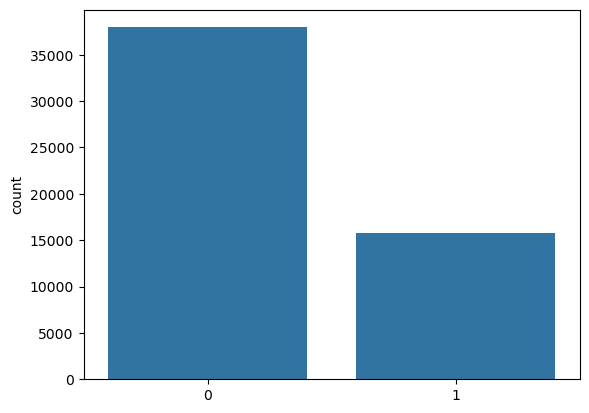

In [48]:
import seaborn as sns
sns.countplot(x = y_train)

from imblearn.over_sampling import SMOTE

sm= SMOTE(random_state= 0)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train, y_train)

print("X_train_balanced 크기: ", X_train_balanced.shape)
print("y_train_balanced 크기: ", y_train_balanced.shape) 

<Axes: ylabel='count'>

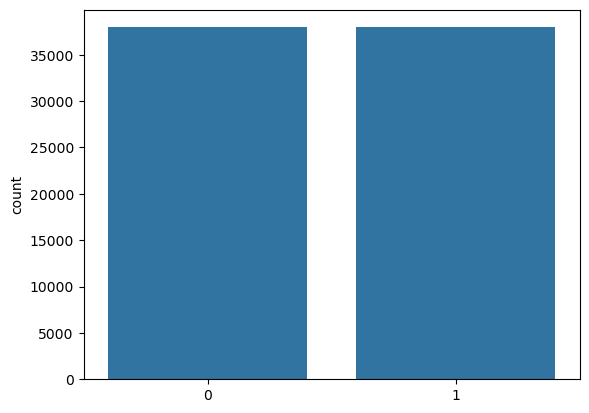

In [49]:
sns.countplot(x=y_train_balanced)

In [50]:
# 밸런싱된 데이터로 의사결정나무 모델 재학습
tree_balanced = DecisionTreeClassifier(random_state=0)  # max_depth 미지정
tree_balanced.fit(X_train_balanced, y_train_balanced)

DecisionTreeClassifier(random_state=0)

In [51]:
# 테스트 데이터에 대해 예측
y_pred_balanced = tree_balanced.predict(X_test)

# 정확도 계산
balanced_acc = accuracy_score(y_test, y_pred_balanced)
print('밸런싱 후 정확도: ', format(balanced_acc))

밸런싱 후 정확도:  0.7408467811903523


In [52]:
# 성능 평가 보고서 출력
balanced_report = classification_report(y_test, y_pred_balanced)
print(balanced_report)

              precision    recall  f1-score   support

           0       0.80      0.84      0.82     16193
           1       0.57      0.51      0.54      6859

    accuracy                           0.74     23052
   macro avg       0.69      0.67      0.68     23052
weighted avg       0.73      0.74      0.74     23052



In [53]:
# 오차 행렬 출력
balanced_cm = confusion_matrix(y_test, y_pred_balanced)
print("오차 행렬:\n", balanced_cm)


오차 행렬:
 [[13604  2589]
 [ 3385  3474]]


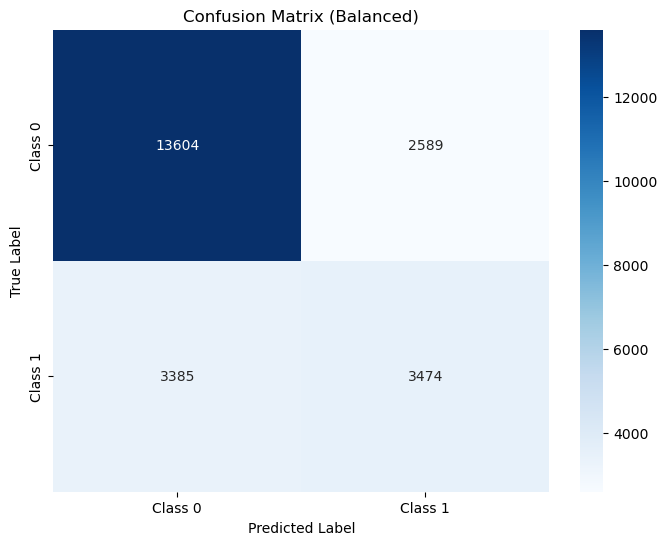

In [54]:
# 오차 행렬 시각화
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(balanced_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix (Balanced)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [55]:
# 변수 중요도 추출
feature_importances = tree.feature_importances_

# 변수 이름 추출
feature_names = airplane.drop(columns=['현황']).columns

# 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

In [56]:
# 결과 출력
print("변수 중요도:")
print(importance_df)

변수 중요도:
      Feature  Importance
5   이슬점온도(°C)    0.195251
4      기온(°C)    0.164268
0     풍향(deg)    0.121054
7   현지기압(hPa)    0.107575
1      풍속(KT)    0.099754
6   해면기압(hPa)    0.096597
9         전운고    0.082327
3    전운량(1/8)    0.049130
2       시정(m)    0.029805
8     강수량(mm)    0.015253
15    남은 휴일 수    0.014842
13      주말 여부    0.007529
10         안개    0.006153
14      휴일 여부    0.005491
12     공휴일 여부    0.002745
11         황사    0.002225


In [57]:
plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows 환경

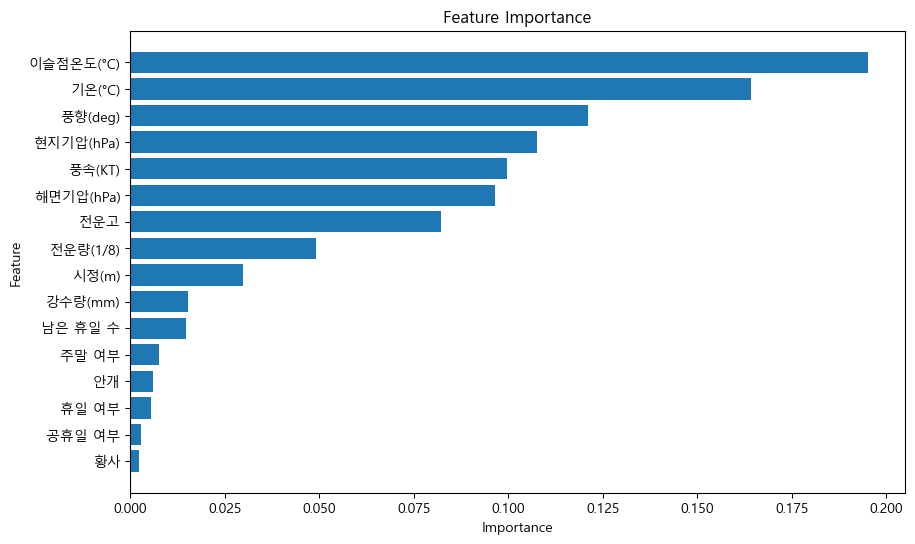

In [58]:
# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # 중요도가 큰 항목이 위로 오도록 정렬
plt.show()

현황 컬럼과 나머지 컬럼 간 상관계수:
현황           1.000000
풍속(KT)       0.075082
풍향(deg)      0.069364
전운량(1/8)     0.055221
이슬점온도(°C)    0.048739
강수량(mm)      0.042231
기온(°C)       0.032373
전운고          0.016120
시정(m)        0.011811
황사          -0.012239
주말 여부       -0.015628
공휴일 여부      -0.022653
휴일 여부       -0.023214
남은 휴일 수     -0.024999
안개          -0.052164
해면기압(hPa)   -0.065021
현지기압(hPa)   -0.065086
Name: 현황, dtype: float64


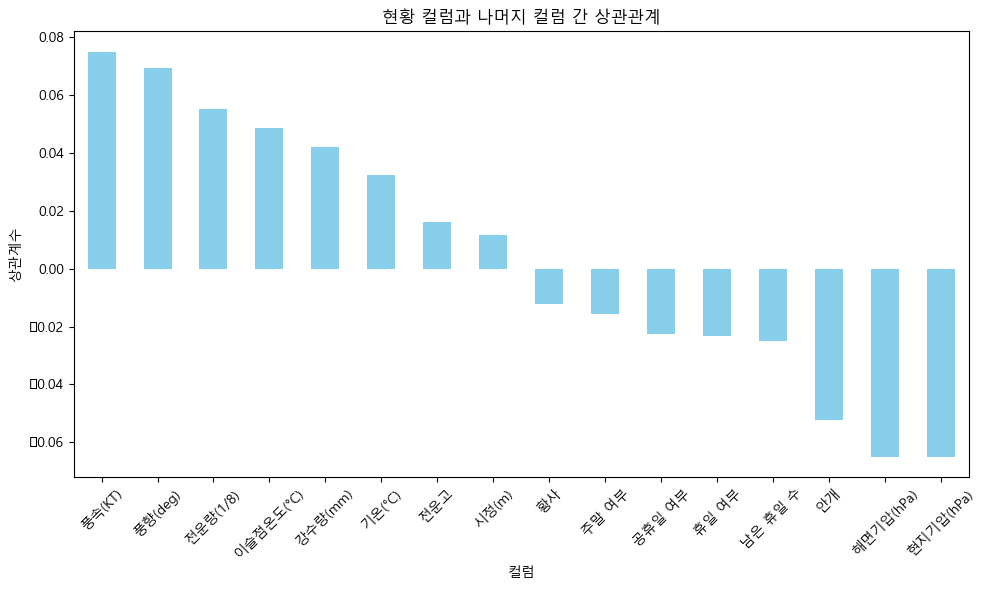

In [59]:
# 숫자형 컬럼만 선택 (현황 포함)
numeric_data = airplane.select_dtypes(include=['float64', 'int32', 'int64', 'uint8'])

# '현황' 컬럼과 나머지 컬럼 간 상관계수 계산
correlation_with_status = numeric_data.corr()['현황'].sort_values(ascending=False)

# 결과 출력
print("현황 컬럼과 나머지 컬럼 간 상관계수:")
print(correlation_with_status)

# 시각화: 막대 그래프
plt.figure(figsize=(10, 6))
correlation_with_status.drop('현황').plot(kind='bar', color='skyblue')  # 현황 자기 자신은 제외
plt.title('현황 컬럼과 나머지 컬럼 간 상관관계')
plt.ylabel('상관계수')
plt.xlabel('컬럼')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
# 변수 중요도 추출
feature_importances = tree_balanced.feature_importances_

# 변수 이름 추출
feature_names = airplane.drop(columns=['현황']).columns

# 중요도를 데이터프레임으로 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

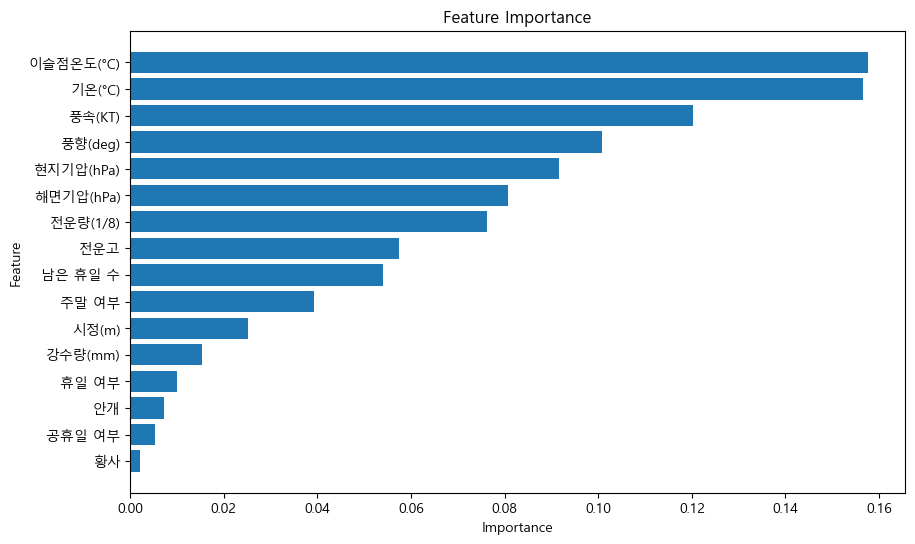

In [61]:
# 변수 중요도 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()  # 중요도가 큰 항목이 위로 오도록 정렬
plt.show()

### 자료 확인 때 쓴 코드들 (과정에 영향 없음)

In [63]:
cloud=airplane.iloc[:,12:26]
cloud.head()
#cloud[(cloud['1층 운량(1/8)']==5.0)].head()
#cloud.iloc[:,4:8].notnull().head()
#len(cloud.dropna())
#cloud.dropna()

,황사,공휴일 여부,주말 여부,휴일 여부,남은 휴일 수
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0


In [64]:
#전체 행 개수
len(airplane)

76840

In [65]:
airplane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76840 entries, 0 to 76839
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   현황         76840 non-null  int64  
 1   풍향(deg)    76840 non-null  float64
 2   풍속(KT)     76840 non-null  float64
 3   시정(m)      76840 non-null  float64
 4   전운량(1/8)   76840 non-null  float64
 5   기온(°C)     76840 non-null  float64
 6   이슬점온도(°C)  76840 non-null  float64
 7   해면기압(hPa)  76840 non-null  float64
 8   현지기압(hPa)  76840 non-null  float64
 9   강수량(mm)    76840 non-null  float64
 10  전운고        76840 non-null  float64
 11  안개         76840 non-null  int32  
 12  황사         76840 non-null  int32  
 13  공휴일 여부     76840 non-null  int32  
 14  주말 여부      76840 non-null  int32  
 15  휴일 여부      76840 non-null  int32  
 16  남은 휴일 수    76840 non-null  int32  
dtypes: float64(10), int32(6), int64(1)
memory usage: 8.2 MB


In [ ]:
airplane[airplane['순간풍속(KT)'].notnull()]

In [ ]:
r=airplane[(airplane['현황'] == '출발')]
r['사유'].isnull().sum()
#airplane['사유'].isnull().sum()
airplane['일기현상'].value_counts()
#airplane.isnull().sum()